In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/haslimafarveen/segmentation/new (1).csv


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/haslimafarveen/segmentation/new (1).csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
#load the dataset
df = pd.read_csv(r"/kaggle/input/datasets/haslimafarveen/segmentation/new (1).csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.shape

(2240, 29)

In [6]:
#data preprocessing
#To get the dataset information
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [7]:
#check the null values in the dataset
for col in df.columns:
    temp=df[col].isnull().sum()
    if temp>0:
        print(f'column{col}contains{temp}null values.')

columnIncomecontains24null values.


In [8]:
#dropping the null values
df=df.dropna()
print("total values in the dataset after removing the null values:",len(df))

total values in the dataset after removing the null values: 2216


In [9]:
#The total number of unique values
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [10]:
#Converting the date column into the three column
parts=df["Dt_Customer"].str.split("-",n=3,expand=True)
df["day"]=parts[0].astype('int')
df["month"]=parts[1].astype('int')
df["year"]=parts[2].astype('int')

In [11]:
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
day                      31
month                    12
year                      3
dtype: int64

In [12]:
#data visualization
floats,objects=[],[]
for col in df.columns:
    if df[col].dtype==object:
        objects.append(col)
    elif df[col].dtype==float:
        floats.append(col)
print(objects)
print(floats)

['Education', 'Marital_Status', 'Dt_Customer']
['Income']


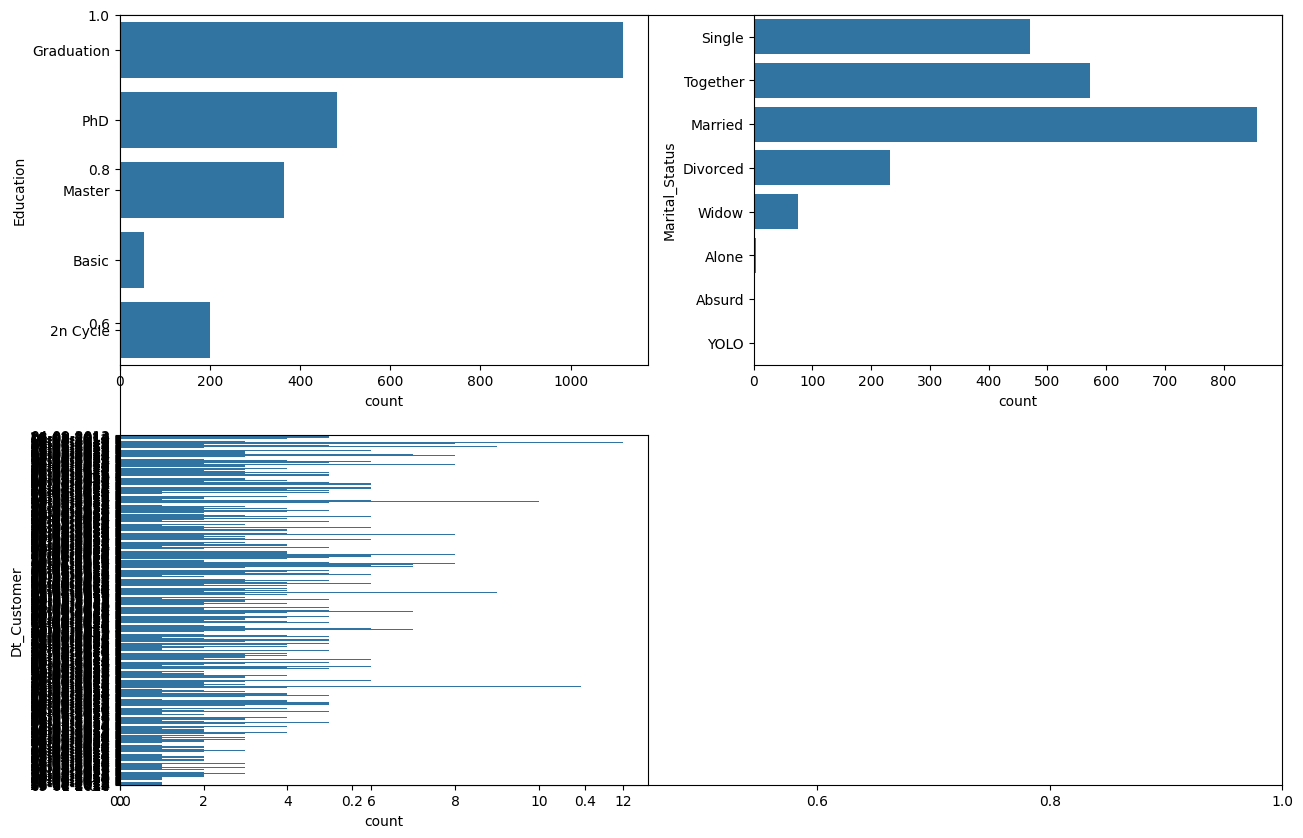

In [13]:
#Count plot for the column of the data type
plt.subplots(figsize=(15, 10))
for i,col in enumerate(objects):
    plt.subplot(2, 2, i + 1)
    sb.countplot(df[col])
plt.show()


In [14]:
#Check the value counts of the Marital status
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

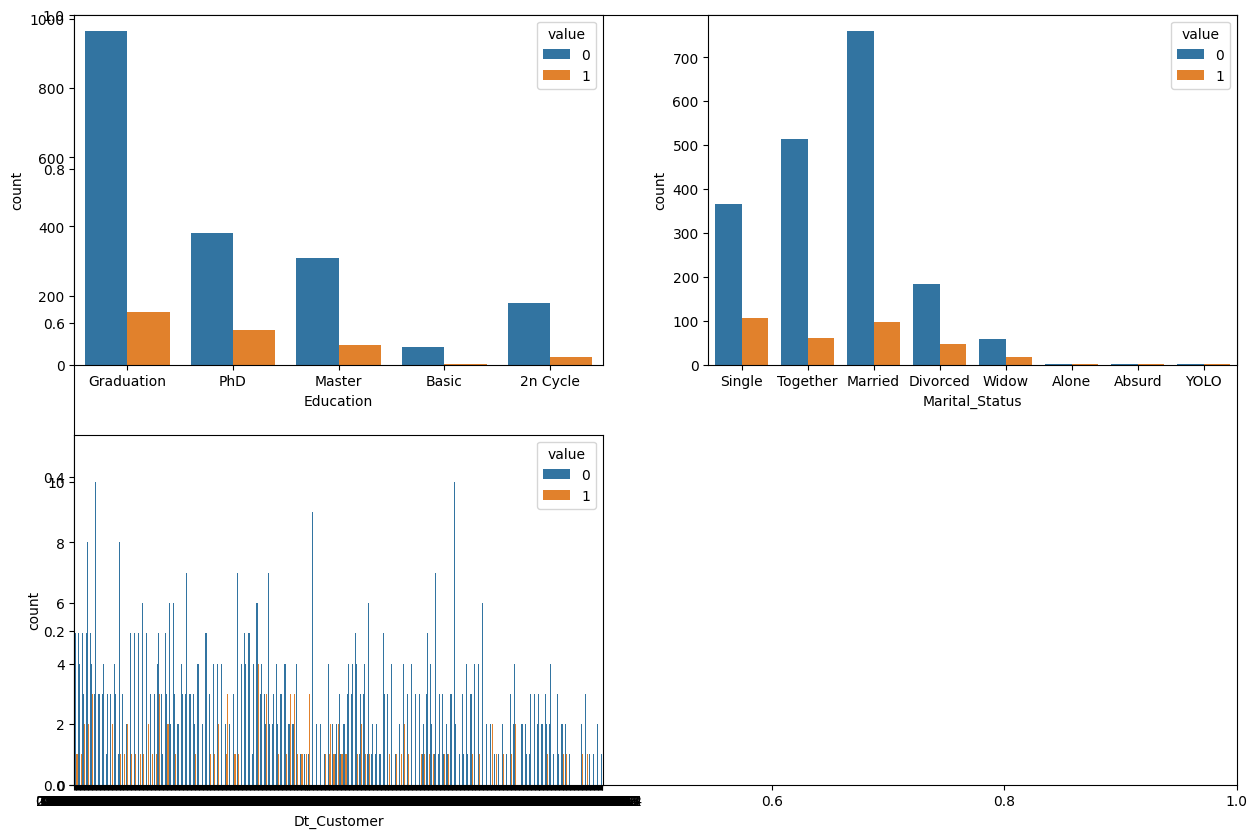

In [15]:
plt.subplots(figsize=(15,10))
for i, col in enumerate(objects):
    plt.subplot(2,2,i+1)
    df_melted=df.melt(id_vars=[col],value_vars=['Response'],var_name='hue')
    sb.countplot(x=col,hue='value',data=df_melted)
plt.show()

In [16]:
for col in df.columns:
    if df[col].dtype==object:
        le=LabelEncoder()
        df[col]=le.fit_transform(df[col])

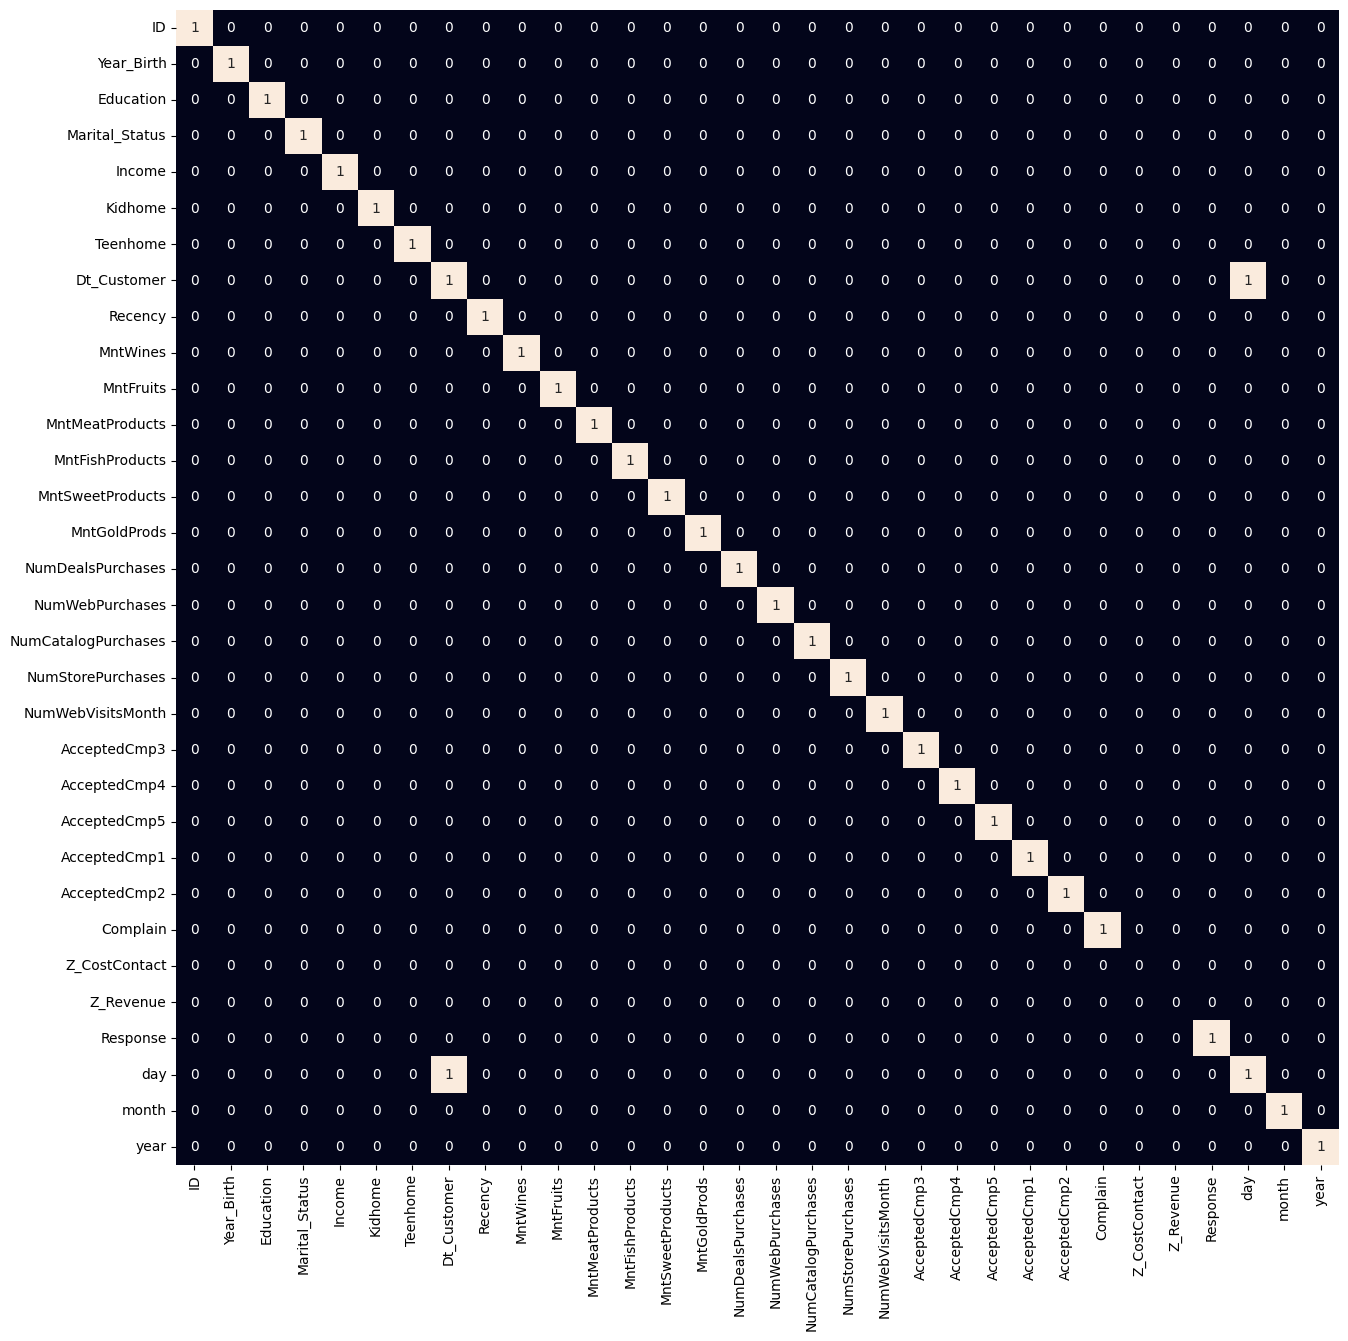

In [17]:
#Heat Map
plt.figure(figsize=(15,15))
sb.heatmap(df.corr()>0.8,annot=True,cbar=False)
plt.show()

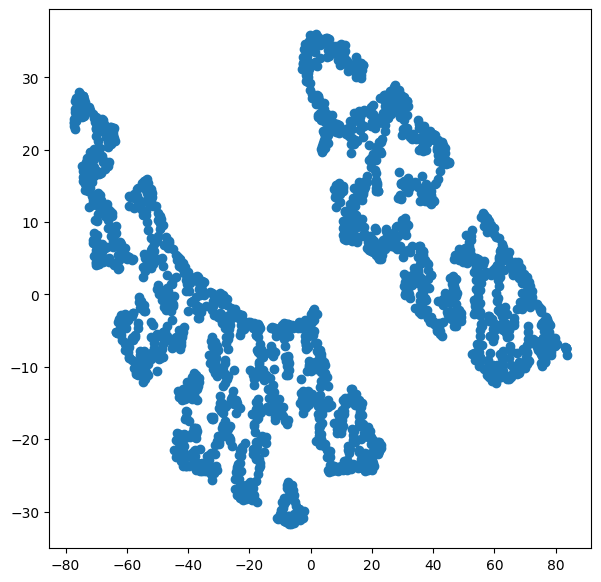

In [18]:
#scatter plot
from sklearn.manifold import TSNE 
model= TSNE(n_components=2,random_state=0)
tsne_data=model.fit_transform(df)
plt.figure(figsize=(7,7))
plt.scatter(tsne_data[:,0],tsne_data[:,1])
plt.show()

In [19]:
error=[]
for n_clusters in range(1,21):
    model=KMeans(init='k-means++',
n_clusters=n_clusters,max_iter=500,random_state=22)
    model.fit(df)
    error.append(model.inertia_)

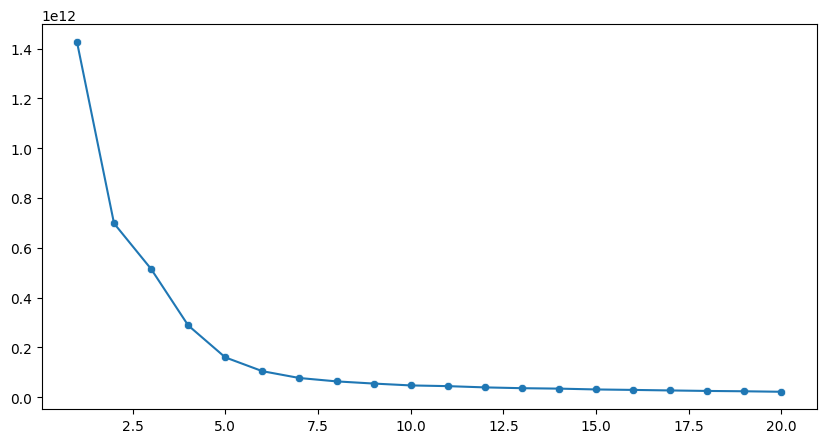

In [20]:
#Elbow Method
plt.figure(figsize=(10,5))
sb.lineplot(x=range(1,21),y=error)
sb.scatterplot(x=range(1,21),y=error)
plt.show()

In [21]:
model=KMeans(init='k-means++',n_clusters=5,max_iter=500,random_state=22)
segments=model.fit_predict(df)

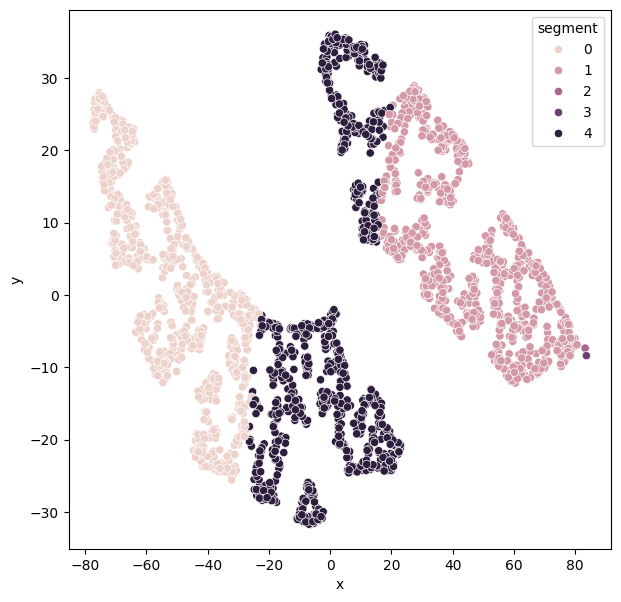

In [22]:
plt.figure(figsize=(7,7))
df_tsne=pd.DataFrame({'x':tsne_data[:,0],'y':tsne_data[:,1],'segment':segments})
sb.scatterplot(x='x',y='y',hue='segment',data=df_tsne)
plt.show()

In [23]:
df=df.drop(['Z_CostContact','Z_Revenue'],axis=1)

In [24]:
#Create Total Spending
df['Total_Spending']=df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df[['Total_Spending']].head()

,Total_Spending
0,1617
1,27
2,776
3,53
4,422


In [25]:
#Created Total Campaign Accepted
df['Total_Accepted']=df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1)
df[['Total_Accepted']].head()

,Total_Accepted
0,0
1,0
2,0
3,0
4,0


In [26]:
#Select feature
x=df[['Income','Total_Spending','NumWebVisitsMonth','Total_Accepted']]
x.head()

,Income,Total_Spending,NumWebVisitsMonth,Total_Accepted
0,58138.0,1617,7,0
1,46344.0,27,5,0
2,71613.0,776,4,0
3,26646.0,53,6,0
4,58293.0,422,5,0


In [27]:
#Apply KMeans
from sklearn.cluster import KMeans
KMeans=KMeans(n_clusters=4,random_state=42)
df['cluster']=KMeans.fit_predict(x)
df[['cluster']].head()

,cluster
0,1
1,0
2,1
3,0
4,1


In [28]:
#Cluster Summary
summary=df.groupby('cluster')[['Income','Total_Spending','NumWebVisitsMonth','Total_Accepted']].mean()
print(summary)

                Income  Total_Spending  NumWebVisitsMonth  Total_Accepted
cluster                                                                  
0         34356.941229      159.876224           6.658949         0.11309
1         69474.625461     1070.261993           3.965867         0.49262
2        152488.000000      689.000000           0.500000         0.00000
3        666666.000000       62.000000           6.000000         0.00000


In [29]:
#Customer Count per cluster
df['cluster'].value_counts()

cluster
0    1123
1    1084
2       8
3       1
Name: count, dtype: int64

<Axes: xlabel='cluster'>

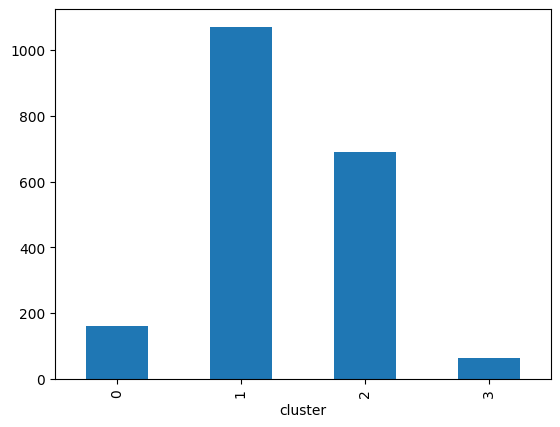

In [30]:
#Business insight  visualization
avg_spending=df.groupby('cluster')['Total_Spending'].mean()
avg_spending.plot(kind='bar')

**Conclusion And Business Insights**

 > **1.Project Summary:**

    This project focuses on customer segmentation using machine learning techniques.
The dataset was processed by handling missing values,transforming date features and creating new features such as total spending and total campaign acceptance.Exploratory data Analysis(EDA) was performed using various visualization to understand customer behaviour and relationship between features

    KMeans clustering was applied to segment customers into distict groups based on income,spending behavior and engagement metrics.The optimal number of clusters was determined using the elbow method.

    The analysis revealed different customer segments,each with unique characteristics.
Based on these segments,business insights were generated to help organizations design targeted marketing strategies,improve customer engagement and increase overall revenue


**CLUSTER EXPLANATION**

CUSTOMER SEGMENTS INTERPRETATION:

   *  CLUSTER 0 - High Value Customer
        > High income and high spending and Frequently Engage with campaigns  

        # BUSINESS STRATEGY:
        > provide loyalty programs and  offer premium services

   *  CLUSTER 1 - Potential Customers
        >High Income but low spending

        # BUSINESS STRATEGY:
        > Target with personalized offers and  Encourage more purchases
  
   * CLUSTER 2 - Impulsive Customers
        > Moderate income with high Spending

        # BUSINESS STRATEGY:
        > Provide discounts and combo offers and  Promote limited-time deals

   * CLUSTER 3 -low Value customers
        >Low income and Low spending

        # BUSINESS STRATEGY:
        > Focus less marketing budget and  Increase awareness campaigns

     
      
      
